In [6]:
import os
os.environ['LD_LIBRARY_PATH'] = os.path.expanduser('~/MultiNest/lib')

import numpy as np
import matplotlib.pyplot as plt

import pymultinest
from species import SpeciesInit
from species.data.database import Database
from species.fit.fit_evolution import FitEvolution
from species.read.read_isochrone import ReadIsochrone
from species.plot.plot_mcmc import plot_posterior
from species.plot.plot_evolution import plot_cooling, plot_isochrones

In [16]:
SpeciesInit()
database = Database()
database.add_isochrones('atmo')
fit_evol = FitEvolution(evolution_model = 'atmo-ceq',
                        log_lum=(-5.88, 0.5),
                        age_prior=(23.2, 2.0, 1.7),
                        mass_prior=None,
                        radius_prior=None,
                        interp_method="linear")

species

Version: 0.11.0
Working folder: /home/kaelan/fyp

Configuration file: /home/kaelan/fyp/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed

------------------
Add isochrone grid
------------------

Evolutionary model: atmo
File name: None
Database tag: None

Unpacking ATMO isochrones (9.6 MB)... [DONE]
Adding isochrones: ATMO equilibrium chemistry... [DONE]
Database tag: atmo-ceq
Adding isochrones: ATMO weak non-equilibrium chemistry... [DONE]
Database tag: atmo-neq-weak
Adding isochrones: ATMO strong non-equilibrium chemistry... [DONE]
Database tag: atmo-neq-strong

----------------------
Fit evolutionary model
----------------------

Evolution model: atmo-ceq
Luminosity log(L/Lsun): (-5.88, 0.5)

Fitting 2 parameters:
   - age
   - mass_0

Uniform priors (min, max):
   - age = (np.float64(1.0), np.float

In [17]:
fit_evol.run_multinest(tag="51eriab",
                       n_live_points=1000,
                       output="./multinest/")


------------------------------
Nested sampling with MultiNest
------------------------------

Database tag: 51eriab
Number of live points: 1000
Output folder: ./multinest/

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 1000
 dimensionality =    2
 *****************************************************

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Param

100%|██████████| 1/1 [00:05<00:00,  5.85s/it]


---------------------
Add posterior samples
---------------------

Database tag: 51eriab
Sampler: multinest
Samples shape: (2852, 5)
ln(Z) = -3.59 +/- 0.02



---------------------
Get posterior samples
---------------------

Database tag: 51eriab
Random samples: None
Samples shape: (2852, 5)

Parameters:
   - age
   - mass_0
   - teff_0
   - radius_0
   - logg_0

Uniform priors (min, max):
   - age = (1.0, 10000.0)
   - mass_0 = (0.5237827573302386, 78.56741359953578)

----------------------------
Plot posterior distributions
----------------------------

Database tag: 51eriab
Object type: planet
Manual parameters: None

Model type: evolution
Model name: atmo-ceq
Sampler: multinest

Show priors: False
Show grid: True

Median parameters:
   - age = 23.23
   - mass_0 = 2.44
   - teff_0 = 612.48
   - radius_0 = 1.27
   - logg_0 = 3.57

Sample with the maximum likelihood:
   - age = 23.01
   - mass_0 = 1.93
   - teff_0 = 546.21
   - radius_0 = 1.26
   - logg_0 = 3.47

Parameters included in corner plot:
   - age
   - mass
   - teff
   - radius
   - logg


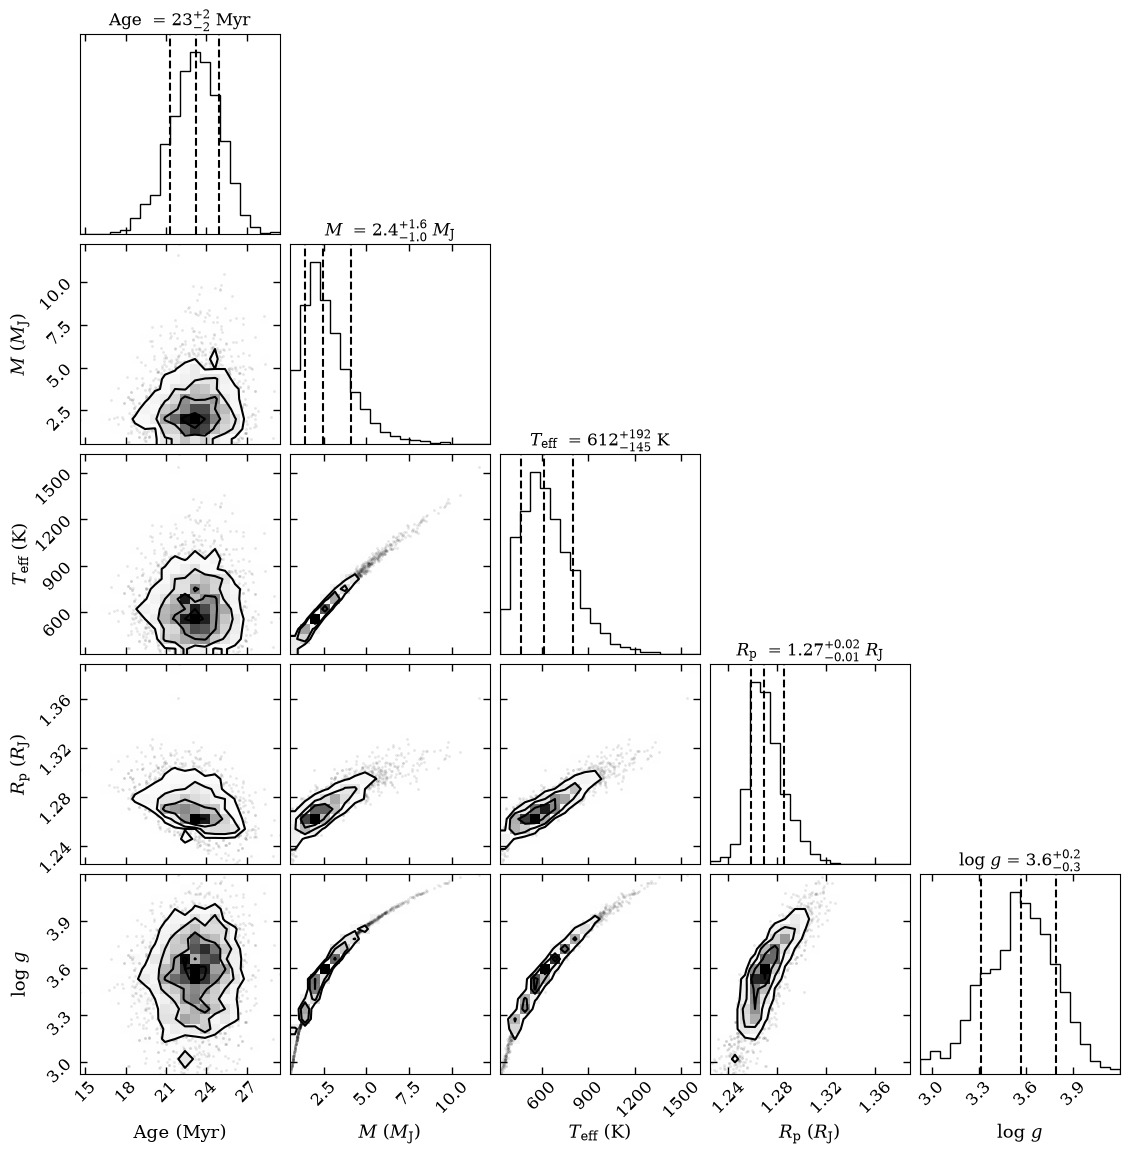

In [18]:
fig = plot_posterior(tag='51eriab',
                     offset=(-0.25, -0.25),
                     title_fmt=['.0f', '.1f', '.0f', '.2f', '.1f'],
                     output=None)

In [19]:
best = database.get_probable_sample('51eriab')


--------------------------------------
Get sample with the maximum likelihood
--------------------------------------

Database tag: 51eriab

Parameters:
   - age = 23.01
   - mass_0 = 1.93
   - teff_0 = 546.21
   - radius_0 = 1.26
   - logg_0 = 3.47



---------------
Plot isochrones
---------------

Database tag: 51eriab
Number of samples: 50

---------------------
Get posterior samples
---------------------

Database tag: 51eriab
Random samples: None
Samples shape: (2852, 5)

Parameters:
   - age
   - mass_0
   - teff_0
   - radius_0
   - logg_0

Uniform priors (min, max):
   - age = (1.0, 10000.0)
   - mass_0 = (0.5237827573302386, 78.56741359953578)

-------------------
Read isochrone grid
-------------------

Database tag: atmo-ceq
Create regular grid: False

Setting 'extra_param' attribute: None

Output: None


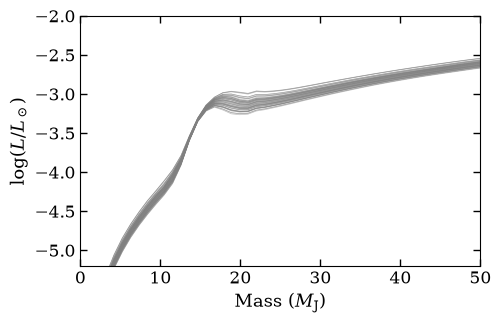

In [20]:
fig, samples_3, indices = plot_isochrones(tag='51eriab',
                                          n_samples=50,
                                          xlim=(0., 50.),
                                          ylim=(-5.2, -2.),
                                          figsize=(4., 2.5),
                                          output=None)